In [ ]:
import sys
!{sys.executable} -m pip install seaborn pyarrow db-dtypes

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery

# Plot settings
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
%matplotlib inline

print("Libraries loaded")

Libraries loaded


In [3]:
PROJECT_ID = "vertex-ml-pipeline-496720"
DATASET    = "predictive_maintenance"
TABLE      = "raw_equipment_data"

client = bigquery.Client(project=PROJECT_ID)

query = f"""
  SELECT *
  FROM `{PROJECT_ID}.{DATASET}.{TABLE}`
"""

df = client.query(query).to_dataframe()
print(f"Loaded {len(df)} rows and {len(df.columns)} columns")
df.head()

/opt/micromamba/envs/jupyterlab/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Loaded 10000 rows and 14 columns


,udi,product_id,type,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,twf,hdf,pwf,osf,rnf
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
print("Dataset shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nBasic statistics:")
df.describe()

Dataset shape: (10000, 14)

Data types:
udi                        Int64
product_id                object
type                      object
air_temperature_k        float64
process_temperature_k    float64
rotational_speed_rpm       Int64
torque_nm                float64
tool_wear_min              Int64
machine_failure            Int64
twf                        Int64
hdf                        Int64
pwf                        Int64
osf                        Int64
rnf                        Int64
dtype: object

Missing values:
udi                      0
product_id               0
type                     0
air_temperature_k        0
process_temperature_k    0
rotational_speed_rpm     0
torque_nm                0
tool_wear_min            0
machine_failure          0
twf                      0
hdf                      0
pwf                      0
osf                      0
rnf                      0
dtype: int64

Basic statistics:


,udi,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,twf,hdf,pwf,osf,rnf
count,10000.0,10000.000000,10000.000000,10000.0,10000.000000,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0
mean,5000.5,300.004930,310.005560,1538.7761,39.986910,107.951,0.0339,0.0046,0.0115,0.0095,0.0098,0.0019
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.0,295.300000,305.700000,1168.0,3.800000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,2500.75,298.300000,308.800000,1423.0,33.200000,53.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,5000.5,300.100000,310.100000,1503.0,40.100000,108.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,7500.25,301.500000,311.100000,1612.0,46.800000,162.0,0.0,0.0,0.0,0.0,0.0,0.0
max,10000.0,304.500000,313.800000,2886.0,76.600000,253.0,1.0,1.0,1.0,1.0,1.0,1.0


Class distribution:
No failure (0): 9661 (96.6%)
Failure    (1): 339 (3.4%)


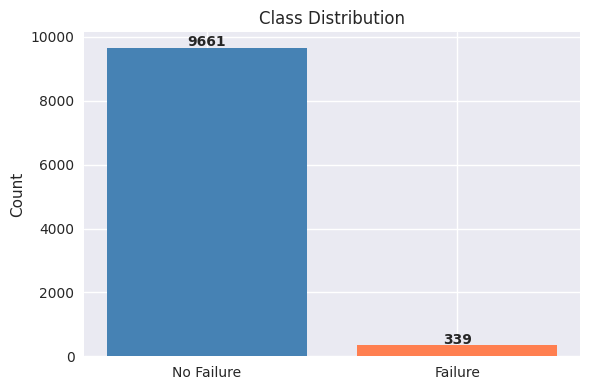

In [5]:
failure_counts = df['machine_failure'].value_counts()
print("Class distribution:")
print(f"No failure (0): {failure_counts[0]} ({failure_counts[0]/len(df)*100:.1f}%)")
print(f"Failure    (1): {failure_counts[1]} ({failure_counts[1]/len(df)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['No Failure', 'Failure'], failure_counts.values, color=['steelblue', 'coral'])
ax.set_title('Class Distribution')
ax.set_ylabel('Count')
for i, v in enumerate(failure_counts.values):
  ax.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

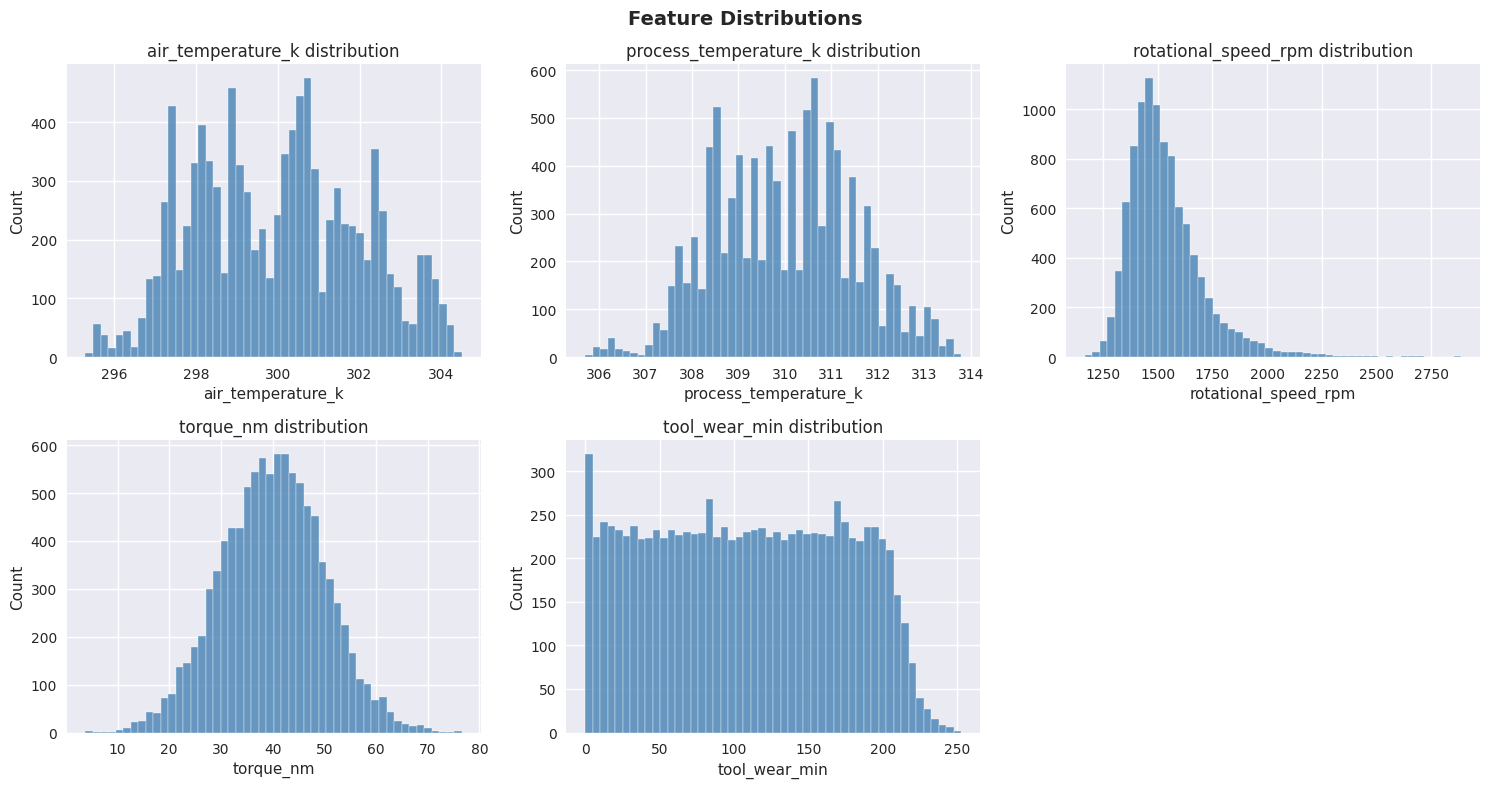

In [6]:
numeric_cols = ['air_temperature_k', 'process_temperature_k', 
                'rotational_speed_rpm', 'torque_nm', 'tool_wear_min']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
  axes[i].hist(df[col], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
  axes[i].set_title(f'{col} distribution')
  axes[i].set_xlabel(col)
  axes[i].set_ylabel('Count')

axes[5].set_visible(False)
plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

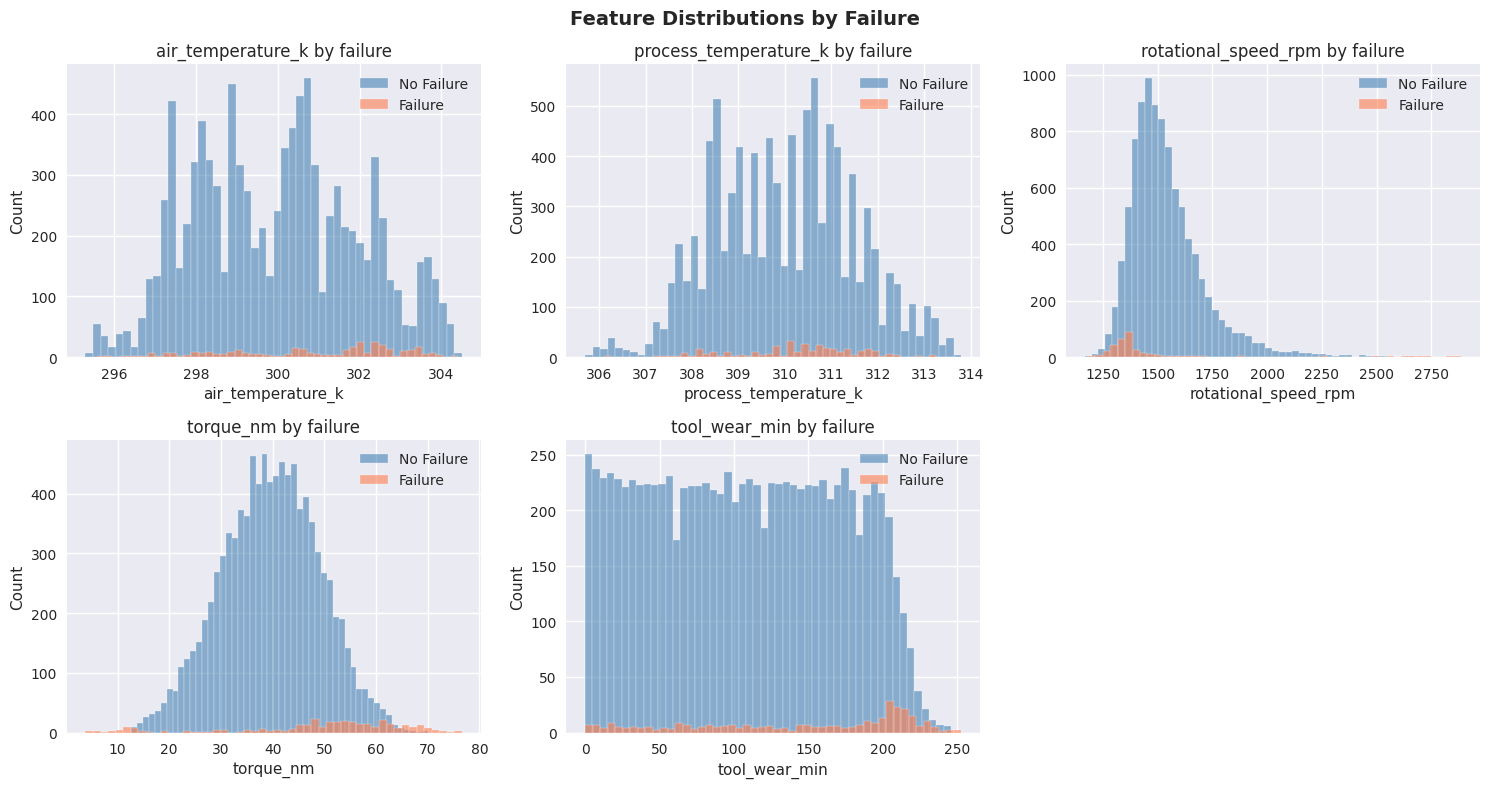

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
  for label, color in [(0, 'steelblue'), (1, 'coral')]:
    subset = df[df['machine_failure'] == label][col]
    axes[i].hist(subset, bins=50, alpha=0.6, color=color, 
                 edgecolor='white', label=f'{"No Failure" if label==0 else "Failure"}')
  axes[i].set_title(f'{col} by failure')
  axes[i].set_xlabel(col)
  axes[i].set_ylabel('Count')
  axes[i].legend()

axes[5].set_visible(False)
plt.suptitle('Feature Distributions by Failure', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# I see that torque is a bell curve. Most to all failures happen at lower rotational speeds (assuming the failure happens before rotational speed can normalize). Failures tend to be skewed to higher torque values, which logically makes sense if you think about binding or something to that extend happening, reducing rotational speed, but increasing torque prior to failure.

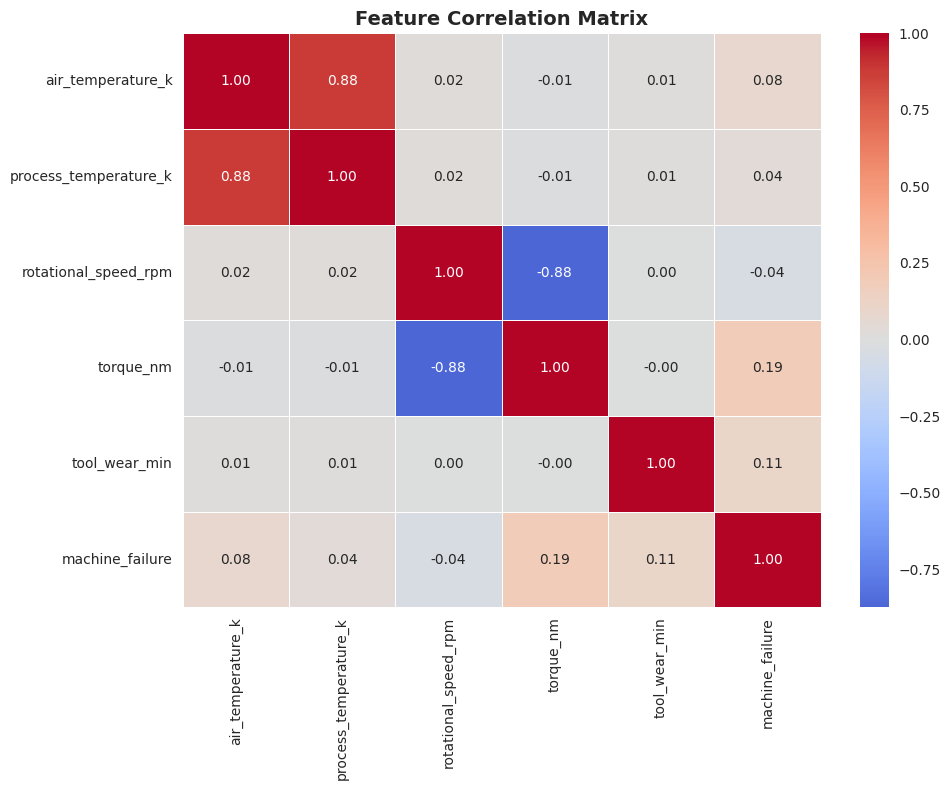

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))

corr_cols = numeric_cols + ['machine_failure']
corr_matrix = df[corr_cols].corr()

sns.heatmap(
  corr_matrix,
  annot=True,
  fmt='.2f',
  cmap='coolwarm',
  center=0,
  ax=ax,
  linewidths=0.5
)

ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

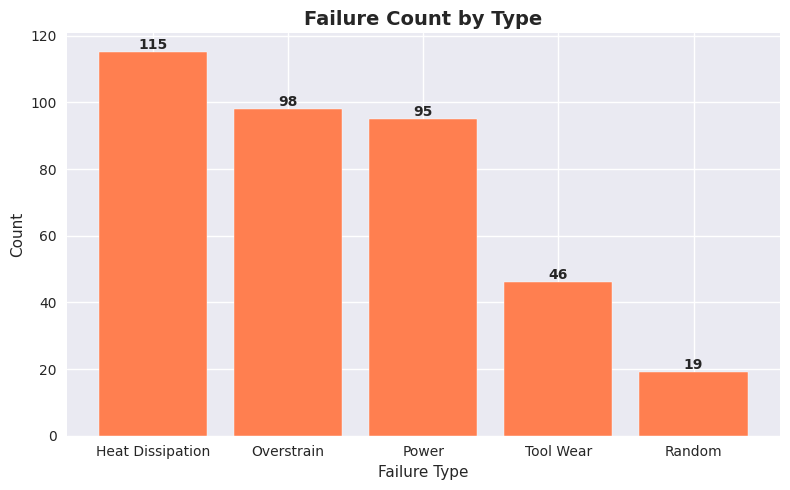

In [12]:
failure_types = ['twf', 'hdf', 'pwf', 'osf', 'rnf']
failure_type_counts = df[failure_types].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(failure_type_counts.index, failure_type_counts.values, color='coral', edgecolor='white')
ax.set_title('Failure Count by Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Failure Type')
ax.set_ylabel('Count')

labels = {
  'twf': 'Tool Wear',
  'hdf': 'Heat Dissipation',
  'pwf': 'Power',
  'osf': 'Overstrain',
  'rnf': 'Random'
}

ax.set_xticks(range(len(failure_type_counts)))
ax.set_xticklabels([labels[t] for t in failure_type_counts.index])
for bar, val in zip(bars, failure_type_counts.values):
  ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
          str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

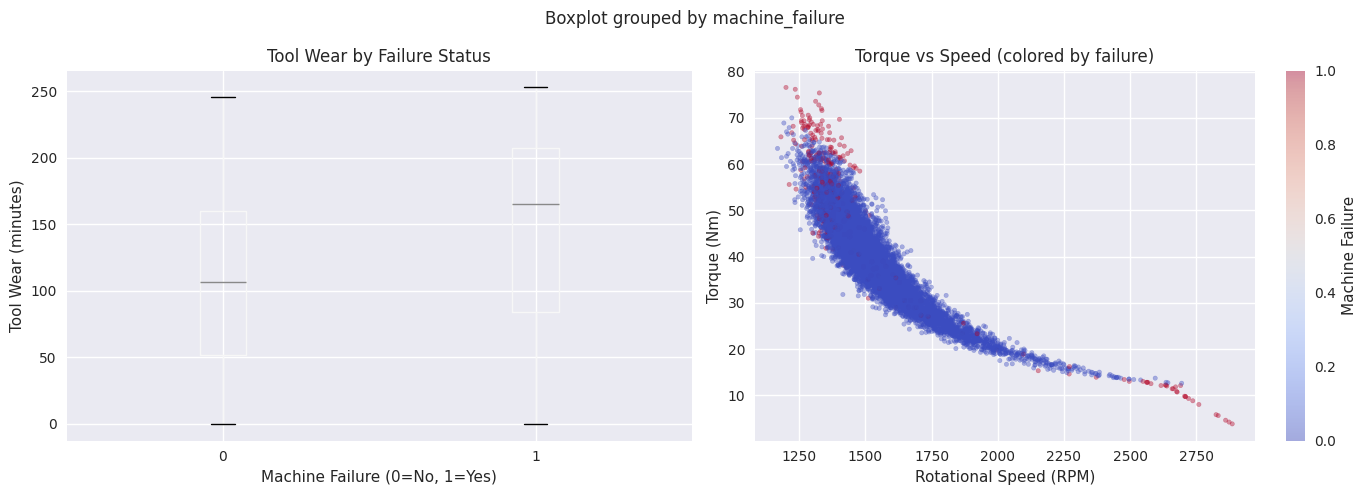

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot of tool wear by failure
df.boxplot(column='tool_wear_min', by='machine_failure', ax=axes[0])
axes[0].set_title('Tool Wear by Failure Status')
axes[0].set_xlabel('Machine Failure (0=No, 1=Yes)')
axes[0].set_ylabel('Tool Wear (minutes)')

# Scatter plot torque vs rotational speed colored by failure
scatter = axes[1].scatter(
  df['rotational_speed_rpm'],
  df['torque_nm'],
  c=df['machine_failure'],
  cmap='coolwarm',
  alpha=0.4,
  s=10
)
axes[1].set_xlabel('Rotational Speed (RPM)')
axes[1].set_ylabel('Torque (Nm)')
axes[1].set_title('Torque vs Speed (colored by failure)')
plt.colorbar(scatter, ax=axes[1], label='Machine Failure')

plt.tight_layout()
plt.show()

In [13]:
# Create the derived features we identified during EDA
df['power_proxy']        = df['torque_nm'] * df['rotational_speed_rpm']
df['torque_speed_ratio'] = df['torque_nm'] / df['rotational_speed_rpm']
df['temp_difference']    = df['process_temperature_k'] - df['air_temperature_k']

# Check correlation of new features with failure
new_features = ['power_proxy', 'torque_speed_ratio', 'temp_difference', 'machine_failure']
print("Correlation of engineered features with machine_failure:")
print(df[new_features].corr()['machine_failure'].sort_values(ascending=False))

Correlation of engineered features with machine_failure:
machine_failure       1.000000
torque_speed_ratio    0.206493
power_proxy           0.176039
temp_difference      -0.111676
Name: machine_failure, dtype: float64


In [14]:
print("=" * 50)
print("EDA SUMMARY — KEY FINDINGS")
print("=" * 50)

print("\n1. CLASS IMBALANCE")
failure_rate = df['machine_failure'].mean() * 100
print(f"   Failure rate: {failure_rate:.1f}%")
print(f"   scale_pos_weight for XGBoost: {(len(df)-df['machine_failure'].sum()) / df['machine_failure'].sum():.1f}")

print("\n2. MOST PREDICTIVE RAW FEATURES")
corr = df[numeric_cols + ['machine_failure']].corr()['machine_failure'].abs().sort_values(ascending=False)
for feat, val in corr[1:].items():
  print(f"   {feat}: {val:.3f}")

print("\n3. ENGINEERED FEATURES")
eng_corr = df[['power_proxy', 'torque_speed_ratio', 'temp_difference', 'machine_failure']].corr()['machine_failure'].abs().sort_values(ascending=False)
for feat, val in eng_corr[1:].items():
  print(f"   {feat}: {val:.3f}")

print("\n4. FAILURE TYPES")
for col in ['twf', 'hdf', 'pwf', 'osf', 'rnf']:
  print(f"   {col}: {df[col].sum()} failures")

print("\n5. RECOMMENDATIONS FOR TRAINING")
print("   - Use scale_pos_weight to handle class imbalance")
print("   - Include torque_speed_ratio as engineered feature")
print("   - Include power_proxy as engineered feature")
print("   - Include temp_difference as engineered feature")
print("   - Evaluate with AUC-ROC and F1, not accuracy")
print("   - Consider log transform on tool_wear_min")

EDA SUMMARY — KEY FINDINGS

1. CLASS IMBALANCE
   Failure rate: 3.4%
   scale_pos_weight for XGBoost: 28.5

2. MOST PREDICTIVE RAW FEATURES
   torque_nm: 0.191
   tool_wear_min: 0.105
   air_temperature_k: 0.083
   rotational_speed_rpm: 0.044
   process_temperature_k: 0.036

3. ENGINEERED FEATURES
   torque_speed_ratio: 0.206
   power_proxy: 0.176
   temp_difference: 0.112

4. FAILURE TYPES
   twf: 46 failures
   hdf: 115 failures
   pwf: 95 failures
   osf: 98 failures
   rnf: 19 failures

5. RECOMMENDATIONS FOR TRAINING
   - Use scale_pos_weight to handle class imbalance
   - Include torque_speed_ratio as engineered feature
   - Include power_proxy as engineered feature
   - Include temp_difference as engineered feature
   - Evaluate with AUC-ROC and F1, not accuracy
   - Consider log transform on tool_wear_min
